<a href="https://colab.research.google.com/github/jennytrujilloq-lab/Ejercicio_Inventario/blob/main/EDAempresasUnicornio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importamos bibliotecas y modulos de python pertinentes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

Cargamos el conjunto de datos, tiene un formato csv y contiene datos sobre empresas unicornio

In [3]:
#Cargar los datos del archivo en un DataFrame y guardaremos en una variable.
companies = pd.read_csv("Unicorn_Companies.csv")

In [ ]:
companies.head(10)

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,2018-01-08,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,2019-05-02,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,2014-12-30,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,2017-12-20,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,2019-02-05,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."


Utilizaremos la propiedas Size de DataFrames para hacernos una idea del tamaño del conjunto de datos

Determinaremos la forma del conjunto de datos.
Identificaremos el numero de filas y columnas del conjunto completo.
Utilizaremos la propiedad SHAPE

In [5]:
companies.size # corresponde a la cantidad de valores que hay en la base

10740

Obtenemos información del conjunto,
Incluyendo el tipo de dato de los valores de cada columna, hay muchas formas de realizar esta tarea, aquí utilizaremos .info

In [ ]:
companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Company           1074 non-null   object
 1   Valuation         1074 non-null   object
 2   Date Joined       1074 non-null   object
 3   Industry          1074 non-null   object
 4   City              1058 non-null   object
 5   Country           1074 non-null   object
 6   Continent         1074 non-null   object
 7   Year Founded      1074 non-null   int64 
 8   Funding           1074 non-null   object
 9   Select Investors  1073 non-null   object
dtypes: int64(1), object(9)
memory usage: 84.0+ KB


Pruebas estadisticas
Esta función genera estadísticas para las columnas numéricas de un conjunto de datos

In [ ]:
companies.describe()

,Year Founded
count,1074.000000
mean,2012.895717
std,5.698573
min,1919.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2021.000000


Convertir Date Joined a datetime

In [6]:
companies["Date Joined"] = pd.to_datetime(companies["Date Joined"])
companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1058 non-null   object        
 5   Country           1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1073 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 84.0+ KB


In [ ]:
companies["Year Joined"] = companies["Date Joined"].dt.year
companies.head()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors,Year Joined
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG",2014
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita...",2011


Resultados y Evaluación

In [ ]:
companies_sample = companies.sample(n = 50, random_state = 42) #semilla o numero  que valida el mismo resultado

Visualizaremos el tiempo que tardaron estas empresas en conseguir el status de Unicornio

In [ ]:
companies_sample["years_till_unicorn"] = companies_sample["Year Joined"] - companies_sample["Year Founded"]

# Agrupamos la data de industria, de la industria con mas valor en el mercado
grouped = (companies_sample[["Industry", "years_till_unicorn"]]
            .groupby("Industry")
            .max()
            .sort_values(by="years_till_unicorn", ascending=False)
          )
display(grouped)

,years_till_unicorn
Industry,
Fintech,21
Health,21
Cybersecurity,19
E-commerce & direct-to-consumer,18
Other,15
Internet software & services,13
"Supply chain, logistics, & delivery",12
Mobile & telecommunications,9
Data management & analytics,8


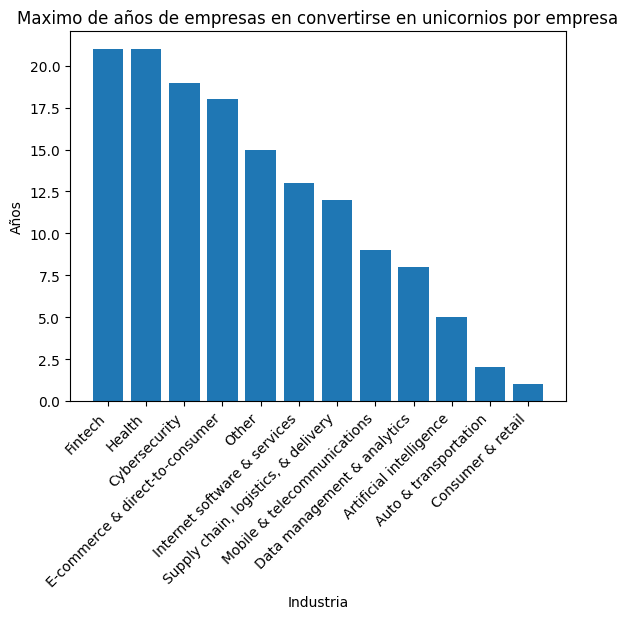

In [ ]:
plt.bar(grouped.index, grouped["years_till_unicorn"])

plt.title("Maximo de años de empresas en convertirse en unicornios por empresa")

plt.xlabel("Industria")
plt.ylabel("Años")

plt.xticks(rotation=45, horizontalalignment='right')

plt.show()